In [1]:
import pandas as pd
import random

random.seed(10)
print(random.random())


import matplotlib.pyplot as plt

0.5714025946899135


### config experiment

In [2]:
import os

working_dir = os.getcwd()
print(working_dir)

parts = working_dir.split("/")

#if parts[-1] == "pipeline":
if parts[-1].startswith("pipeline"): ### BUG SOLVED MAY 2025
    pipeline = working_dir
else:
    pipeline ="/".join(parts[:-1])
print(pipeline)

/home/ematos/phd/pipeline_city/GRAFICOS
/home/ematos/phd/pipeline_city


In [3]:
import sys 
base = pipeline
sys.path.append(base)

from config.configsite import *

#print(f"filesdir = {filesdir}") # new AT april 2025
print(f"pipeline = {pipeline}") # new AT april 2025


#inputdir=pipeline+"JOIN_MAPPER_REBEL/"+resultsdir
inputdir=pipeline+"NEW_INDOMAIN_NER_FLAIR/"+resultsdir   # AT 24 de maio 2025

print(f"input dir = {inputdir}") # new AT may 2025

outputdir=pipeline+"NEW_INDOMAIN_NER_FLAIR/"+resultsdir
print(f"output dir = {outputdir}") # new AT may 2025

os.makedirs(outputdir, exist_ok=True)

pipeline = /home/ematos/phd/pipeline_city/
input dir = /home/ematos/phd/pipeline_city/NEW_INDOMAIN_NER_FLAIR/OUTPUT_RESULTS/
output dir = /home/ematos/phd/pipeline_city/NEW_INDOMAIN_NER_FLAIR/OUTPUT_RESULTS/


In [4]:
# tag column to use
#tag_column = "ner1"
tag_column = "ner2"  # 1 class only


# diretory for dataset to be USE - NEW 25 october ---------------
top = 10
train_percent = 60 # can be 25, 50 and 75
test_percent = 30 # can only be 10
dev_percent = 10 # can only be 10

dataset_dir = inputdir+"dataset_bert_and_mapper/"
print(f"input dataset dir = {dataset_dir}") # new AT may 2025


#dataset_dir = f"/home/ematos/phd/pt/NEW_INDOMAIN_NER_FLAIR/data_bert_and_mapper_2025/"
#dataset_dir = f"./train/datawikiner_{top}class_train{train_percent}_dev{dev_percent}_test{test_percent}/"

input dataset dir = /home/ematos/phd/pipeline_city/NEW_INDOMAIN_NER_FLAIR/OUTPUT_RESULTS/dataset_bert_and_mapper/


In [5]:
# foundation model to be fine tuned
#modelo_base="Geotrend/bert-base-pt-cased"
#link https://huggingface.co/Geotrend/bert-base-pt-cased
modelo_base="vocabtrimmer/xlm-roberta-base-trimmed-pt-60000"
#link https://huggingface.co/vocabtrimmer/xlm-roberta-base-trimmed-pt-60000
print(f"model base = {modelo_base}") 

    
#modelo_base_short="bert-base-pt-cased"
modelo_base_short = "xlm-roberta-base-trimmed-pt-60000"
print(f"model base short = {modelo_base_short}") 

# dir and name for model to be created
#model_created =f'/home/ematos/phd/pt/NEW_INDOMAIN_NER_FLAIR/data_bert_and_mapper_2025'
model_created = inputdir+"dataset_bert_and_mapper/"

#model_created = f'resources/taggers/ner_1class_{top}_{modelo_base_short}_{train_percent}p'

model base = vocabtrimmer/xlm-roberta-base-trimmed-pt-60000
model base short = xlm-roberta-base-trimmed-pt-60000


In [6]:
dataset_dir

'/home/ematos/phd/pipeline_city/NEW_INDOMAIN_NER_FLAIR/OUTPUT_RESULTS/dataset_bert_and_mapper/'

In [7]:
filename = "loss.tsv"
df = pd.read_csv(dataset_dir + filename, sep = "\t")
df

,EPOCH,TIMESTAMP,LEARNING_RATE,TRAIN_LOSS,DEV_LOSS,DEV_PRECISION,DEV_RECALL,DEV_F1,DEV_ACCURACY
0,1,19:00:16,0.0,2.9971,0.1455,0.0000,0.0000,0.0000,0.0000
1,2,19:00:51,0.0,0.5100,0.1263,0.0000,0.0000,0.0000,0.0000
2,3,19:01:26,0.0,0.4961,0.0853,0.8571,0.6667,0.7500,0.6000
3,4,19:02:00,0.0,0.4605,0.0665,0.8776,0.6825,0.7679,0.6232
4,5,19:02:34,0.0,0.4445,0.0600,0.7963,0.6825,0.7350,0.5811
5,6,19:03:09,0.0,0.4087,0.0580,0.8113,0.6825,0.7414,0.5972
6,7,19:03:43,0.0,0.4179,0.0562,0.8269,0.6825,0.7478,0.6056
7,8,19:04:18,0.0,0.4155,0.0566,0.7963,0.6825,0.7350,0.5890
8,9,19:04:53,0.0,0.4079,0.0557,0.8113,0.6825,0.7414,0.5972
9,10,19:05:28,0.0,0.3992,0.0573,0.7818,0.6825,0.7288,0.5811


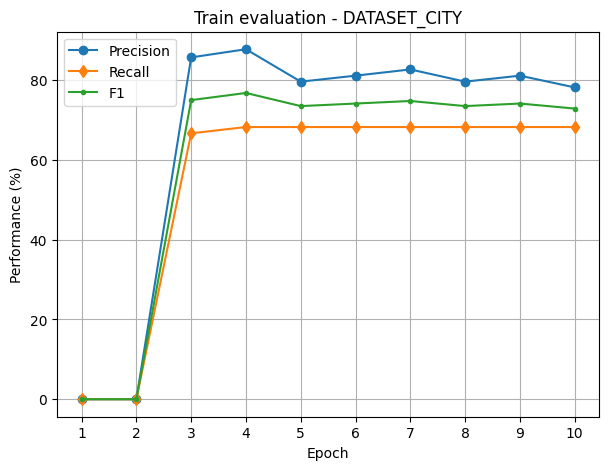

In [9]:
from matplotlib.ticker import MaxNLocator

# DONE 15 july 2025
plt.figure(figsize=(3.5*2, 2.5*2))  # good for single-column

plt.plot(df.EPOCH, df.DEV_PRECISION*100, marker='o')
plt.plot(df.EPOCH, df.DEV_RECALL*100,marker='d')

plt.plot(df.EPOCH, df.DEV_F1*100, marker =".")
plt.grid()
plt.xticks=range(20)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel("Epoch")
plt.ylabel("Performance (%)")
plt.title(f"Train evaluation - {dataset}")


plt.legend(["Precision","Recall","F1"])

plt.savefig(f"treino-flair-{dataset}.png")